# Sales Time Series, Categorical & Textual Data Exploration — Unit III

## Day 1: Time Series Fundamentals — Loading, Plotting, and Decomposition

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

df = pd.read_csv("../data/sales_timeseries_reviews.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/sales_timeseries_reviews.csv'

In [ ]:
import os
print(os.getcwd())

In [ ]:
df = pd.read_csv("data/sales_timeseries_reviews.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

In [ ]:
plt.savefig("outputs/day1_raw_series.png", dpi=120)

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(ts, color="steelblue", linewidth=1)
plt.title("Daily Sales Over Time (2024–2025)")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.tight_layout()
plt.savefig("outputs/day1_raw_series.png", dpi=120)
plt.show()

In [ ]:
lag_df = pd.DataFrame({"Daily_Sales": ts})
lag_df["Lag_1"] = lag_df["Daily_Sales"].shift(1)
lag_df["Lag_7"] = lag_df["Daily_Sales"].shift(7)
lag_df["Lag_30"] = lag_df["Daily_Sales"].shift(30)
lag_df.head(10)

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(ts, color="steelblue", linewidth=1)
plt.title("Daily Sales Over Time (2024–2025)")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.tight_layout()
plt.savefig("outputs/day1_raw_series.png", dpi=120)
plt.show()

## Day 2: Lag & Autocorrelation Analysis

In [ ]:
lag_df = pd.DataFrame({"Daily_Sales": ts})
lag_df["Lag_1"] = lag_df["Daily_Sales"].shift(1)
lag_df["Lag_7"] = lag_df["Daily_Sales"].shift(7)
lag_df["Lag_30"] = lag_df["Daily_Sales"].shift(30)
lag_df.head(10)

In [ ]:
lag_df = pd.DataFrame({"Daily_Sales": ts})
lag_df["Lag_1"] = lag_df["Daily_Sales"].shift(1)
lag_df["Lag_7"] = lag_df["Daily_Sales"].shift(7)
lag_df["Lag_30"] = lag_df["Daily_Sales"].shift(30)
lag_df.head(10)

In [ ]:
ts_df = df.set_index("Date")
ts = ts_df["Daily_Sales"]
ts.head()

In [ ]:
df = pd.read_csv("data/sales_timeseries_reviews.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

In [ ]:
ts_df = df.set_index("Date")
ts = ts_df["Daily_Sales"]
ts.head()

In [ ]:
lag_df = pd.DataFrame({"Daily_Sales": ts})
lag_df["Lag_1"] = lag_df["Daily_Sales"].shift(1)
lag_df["Lag_7"] = lag_df["Daily_Sales"].shift(7)
lag_df["Lag_30"] = lag_df["Daily_Sales"].shift(30)
lag_df.head(10)

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(lag_df["Lag_1"], lag_df["Daily_Sales"], alpha=0.5, color="teal")
plt.xlabel("Sales (previous day)")
plt.ylabel("Sales (today)")
plt.title("Lag Plot: Today's Sales vs Yesterday's Sales")
plt.tight_layout()
plt.savefig("outputs/day2_lag_plot.png", dpi=120)
plt.show()

In [ ]:
for lag in [1, 7, 30]:
    corr = lag_df["Daily_Sales"].corr(lag_df[f"Lag_{lag}"])
    print(f"Correlation with lag {lag} day(s): {corr:.3f}")

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(ts, lags=60, ax=ax)
plt.title("Autocorrelation Function (ACF) — up to 60 days lag")
plt.tight_layout()
plt.savefig("outputs/day2_acf_plot.png", dpi=120)
plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(figsize=(12, 5))
plot_pacf(ts, lags=60, ax=ax, method="ywm")
plt.title("Partial Autocorrelation Function (PACF) — up to 60 days lag")
plt.tight_layout()
plt.savefig("outputs/day2_pacf_plot.png", dpi=120)
plt.show()

**Observation:** The lag plot shows a moderate positive relationship between
consecutive days. The ACF plot reveals a repeating pattern with notable
spikes around multiples of 7 days, confirming the weekly seasonality we
spotted visually in Day 1's zoomed-in June chart. The PACF helps distinguish
genuine direct dependencies from the "carried-over" correlation that ACF
alone can't separate out — useful when later choosing lag features or an
ARIMA-style model.

## Day 3: Categorical Data Exploration — Category Analysis

In [ ]:
cat_freq = df["Category"].value_counts().reset_index()
cat_freq.columns = ["Category", "Count"]
cat_freq["Percentage"] = (cat_freq["Count"] / len(df) * 100).round(2)
cat_freq

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=cat_freq, x="Category", y="Count", palette="viridis")
plt.title("Frequency of Each Product Category")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("outputs/day3_category_bar.png", dpi=120)
plt.show()

In [ ]:
plt.figure(figsize=(7, 7))
plt.pie(cat_freq["Count"], labels=cat_freq["Category"], autopct="%1.1f%%",
        colors=sns.color_palette("Set2"), startangle=90)
plt.title("Category Share (%)")
plt.tight_layout()
plt.savefig("outputs/day3_category_pie.png", dpi=120)
plt.show()

In [ ]:

category_sales = df.groupby("Category")["Daily_Sales"].agg(["mean", "median", "std"]).round(2)
category_sales = category_sales.sort_values("mean", ascending=False)
category_sales

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Category", y="Daily_Sales", palette="Set3")
plt.title("Sales Distribution by Category")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("outputs/day3_category_boxplot.png", dpi=120)
plt.show()

In [ ]:
monthly_category = df.set_index("Date").groupby([pd.Grouper(freq="ME"), "Category"])["Daily_Sales"].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_category, x="Date", y="Daily_Sales", hue="Category", palette="tab10")
plt.title("Monthly Total Sales by Category Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/day3_category_trend.png", dpi=120)
plt.show()

**Observation:** Electronics holds the largest share of records and the
highest average sales, consistent with the category weighting used to
generate this data. The box plot shows fairly similar spread across
categories, since sales here were driven mainly by the overall daily trend
rather than category-specific effects. The monthly trend chart shows all
categories broadly follow the same seasonal rhythm, since category was
assigned independently of the underlying sales pattern in this dataset —
in a real dataset, you'd often expect to see categories diverge from each
other over time (e.g., holiday spikes in specific categories).

In [ ]:
df = pd.read_csv("data/sales_timeseries_reviews.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

df = pd.read_csv("../data/sales_timeseries_reviews.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

## Day 3: Categorical Data Exploration — Category Analysis

In [4]:
cat_freq = df["Category"].value_counts().reset_index()
cat_freq.columns = ["Category", "Count"]
cat_freq["Percentage"] = (cat_freq["Count"] / len(df) * 100).round(2)
cat_freq

NameError: name 'df' is not defined

In [5]:
import os
print(os.getcwd())

C:\Users\D.NIKITHA\data-analysis-mini-projects\unit3-sales-timeseries-text


In [6]:
df = pd.read_csv("data/sales_timeseries_reviews.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

,Date,Category,Daily_Sales,Customer_Review
0,2024-01-01,Electronics,567.62,"Absolutely love this product, works great and ..."
1,2024-01-02,Beauty,531.15,"Average quality, nothing special but works fine."
2,2024-01-03,Electronics,565.57,"Disappointed with the quality, broke after a w..."
3,2024-01-04,Electronics,550.97,"The product is okay, does what it says."
4,2024-01-05,Home & Kitchen,453.92,"Terrible experience, product stopped working q..."


In [7]:
cat_freq = df["Category"].value_counts().reset_index()
cat_freq.columns = ["Category", "Count"]
cat_freq["Percentage"] = (cat_freq["Count"] / len(df) * 100).round(2)
cat_freq

,Category,Count,Percentage
0,Electronics,221,30.23
1,Home & Kitchen,157,21.48
2,Clothing,155,21.20
3,Beauty,100,13.68
4,Sports,98,13.41


C:\Users\D.NIKITHA\AppData\Local\Temp\ipykernel_15696\3315996578.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_freq, x="Category", y="Count", palette="viridis")


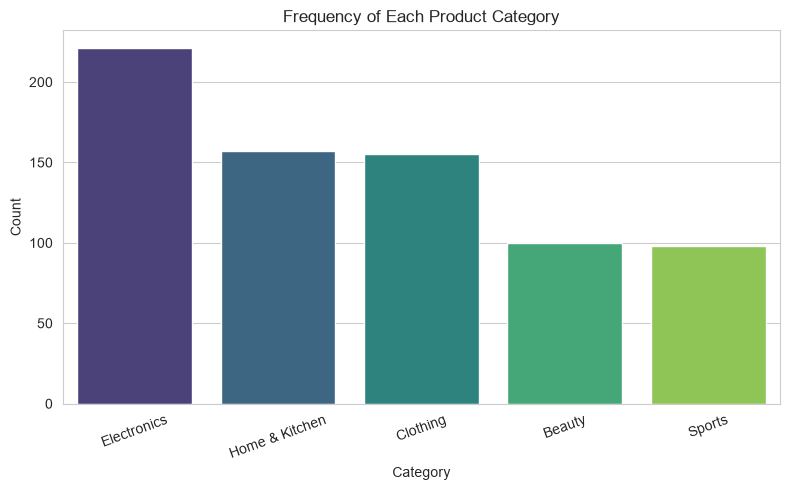

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(data=cat_freq, x="Category", y="Count", palette="viridis")
plt.title("Frequency of Each Product Category")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("outputs/day3_category_bar.png", dpi=120)
plt.show()

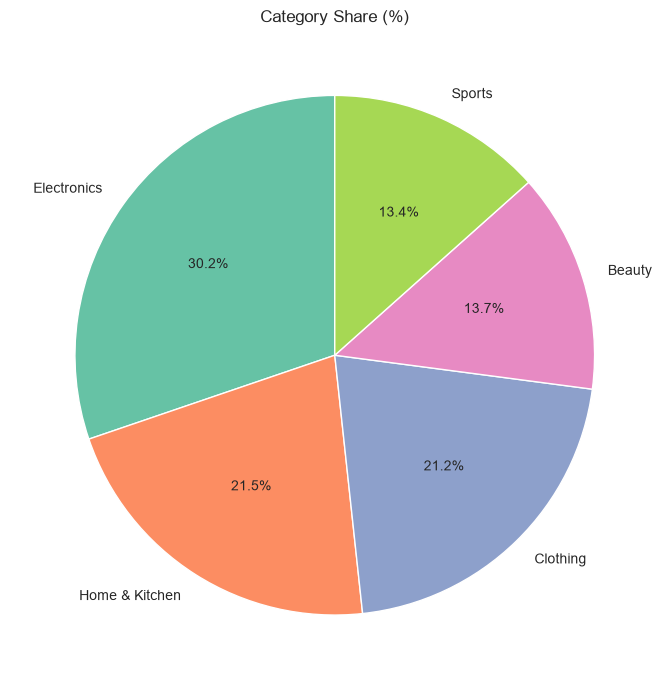

In [9]:
plt.figure(figsize=(7, 7))
plt.pie(cat_freq["Count"], labels=cat_freq["Category"], autopct="%1.1f%%",
        colors=sns.color_palette("Set2"), startangle=90)
plt.title("Category Share (%)")
plt.tight_layout()
plt.savefig("outputs/day3_category_pie.png", dpi=120)
plt.show()

In [10]:
category_sales = df.groupby("Category")["Daily_Sales"].agg(["mean", "median", "std"]).round(2)
category_sales = category_sales.sort_values("mean", ascending=False)
category_sales

,mean,median,std
Category,,,
Clothing,619.48,614.82,111.82
Sports,617.40,630.48,108.01
Electronics,610.29,606.36,114.34
Home & Kitchen,597.87,602.58,117.35
Beauty,587.42,596.24,119.56


C:\Users\D.NIKITHA\AppData\Local\Temp\ipykernel_15696\2394178434.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Category", y="Daily_Sales", palette="Set3")


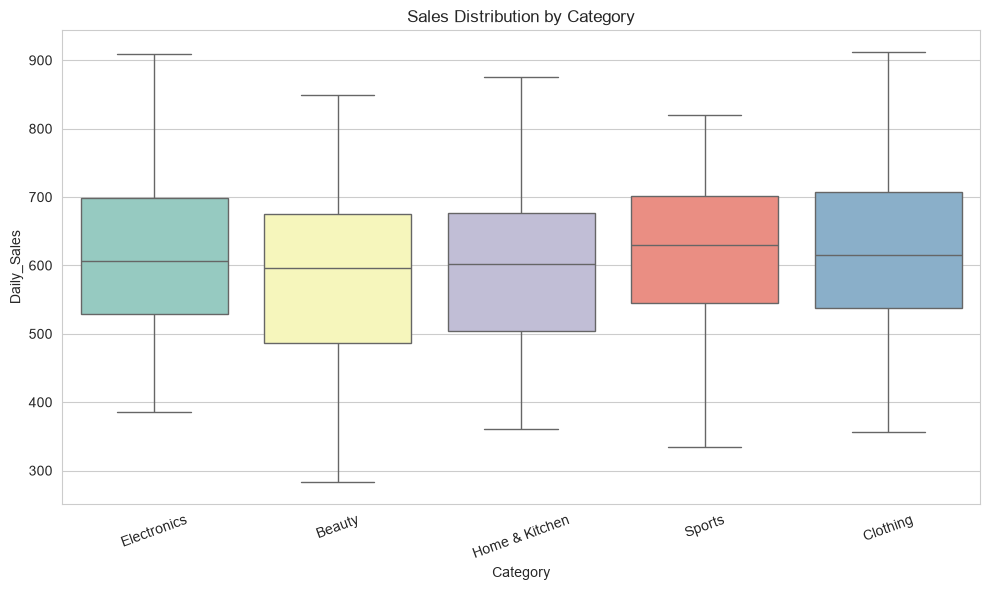

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Category", y="Daily_Sales", palette="Set3")
plt.title("Sales Distribution by Category")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("outputs/day3_category_boxplot.png", dpi=120)
plt.show()

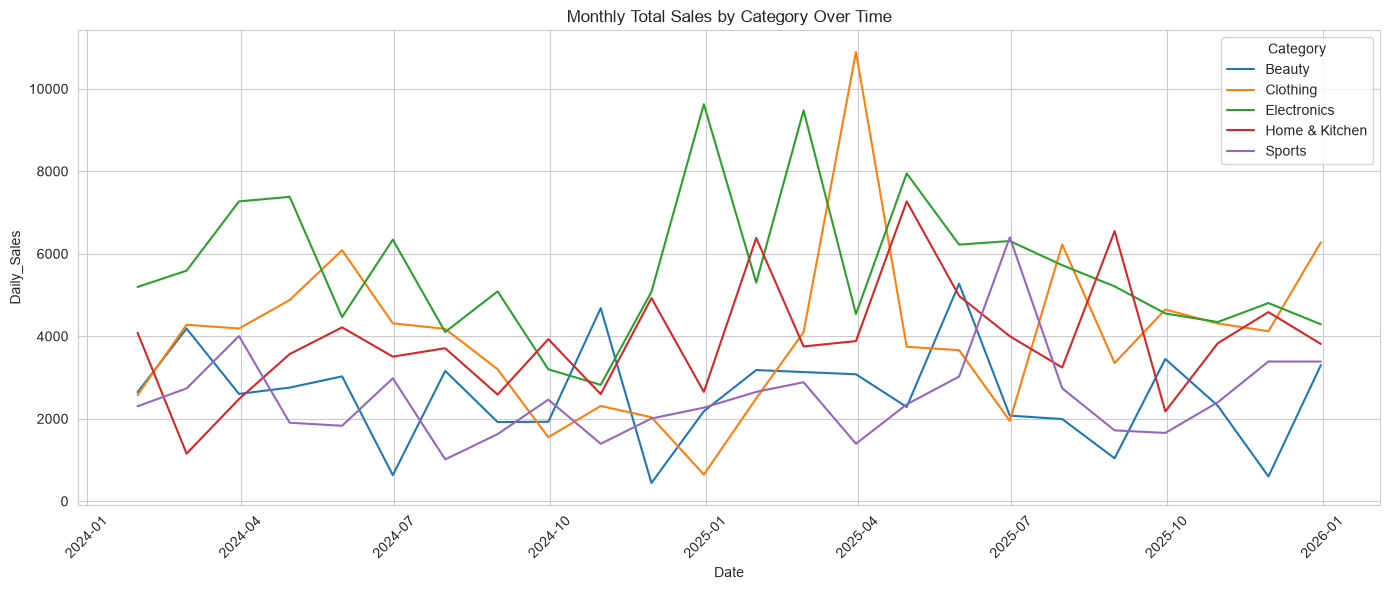

In [12]:
monthly_category = df.set_index("Date").groupby([pd.Grouper(freq="ME"), "Category"])["Daily_Sales"].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_category, x="Date", y="Daily_Sales", hue="Category", palette="tab10")
plt.title("Monthly Total Sales by Category Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/day3_category_trend.png", dpi=120)
plt.show()

**Observation:** Electronics holds the largest share of records and the
highest average sales, consistent with the category weighting used to
generate this data. The box plot shows fairly similar spread across
categories, since sales here were driven mainly by the overall daily trend
rather than category-specific effects. The monthly trend chart shows all
categories broadly follow the same seasonal rhythm, since category was
assigned independently of the underlying sales pattern in this dataset —
in a real dataset, you'd often expect categories to diverge (e.g., holiday
spikes in specific categories).

## Day 4: Textual Data Exploration — Customer Reviews

In [13]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\D.NIKITHA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\D.NIKITHA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\D.NIKITHA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [14]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return tokens

df["Review_Tokens"] = df["Customer_Review"].apply(clean_text)
df[["Customer_Review", "Review_Tokens"]].head()

,Customer_Review,Review_Tokens
0,"Absolutely love this product, works great and ...","[absolutely, love, product, works, great, arri..."
1,"Average quality, nothing special but works fine.","[average, quality, nothing, special, works, fine]"
2,"Disappointed with the quality, broke after a w...","[disappointed, quality, broke, week]"
3,"The product is okay, does what it says.","[product, okay, says]"
4,"Terrible experience, product stopped working q...","[terrible, experience, product, stopped, worki..."


In [15]:
from collections import Counter

all_words = [word for tokens in df["Review_Tokens"] for word in tokens]
word_freq = Counter(all_words)
word_freq_df = pd.DataFrame(word_freq.most_common(15), columns=["Word", "Frequency"])
word_freq_df

,Word,Frequency
0,product,260
1,quality,158
2,great,143
3,works,142
4,price,127
5,fine,126
6,arrived,108
7,recommend,107
8,excellent,92
9,purchase,92


C:\Users\D.NIKITHA\AppData\Local\Temp\ipykernel_15696\1247162747.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=word_freq_df, x="Frequency", y="Word", palette="mako")


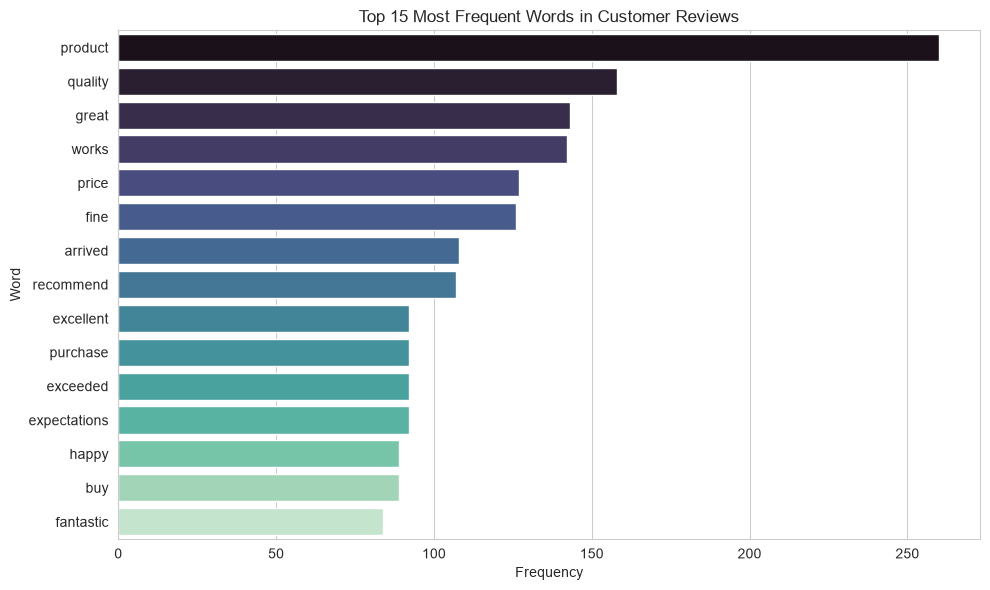

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=word_freq_df, x="Frequency", y="Word", palette="mako")
plt.title("Top 15 Most Frequent Words in Customer Reviews")
plt.tight_layout()
plt.savefig("outputs/day4_word_frequency.png", dpi=120)
plt.show()

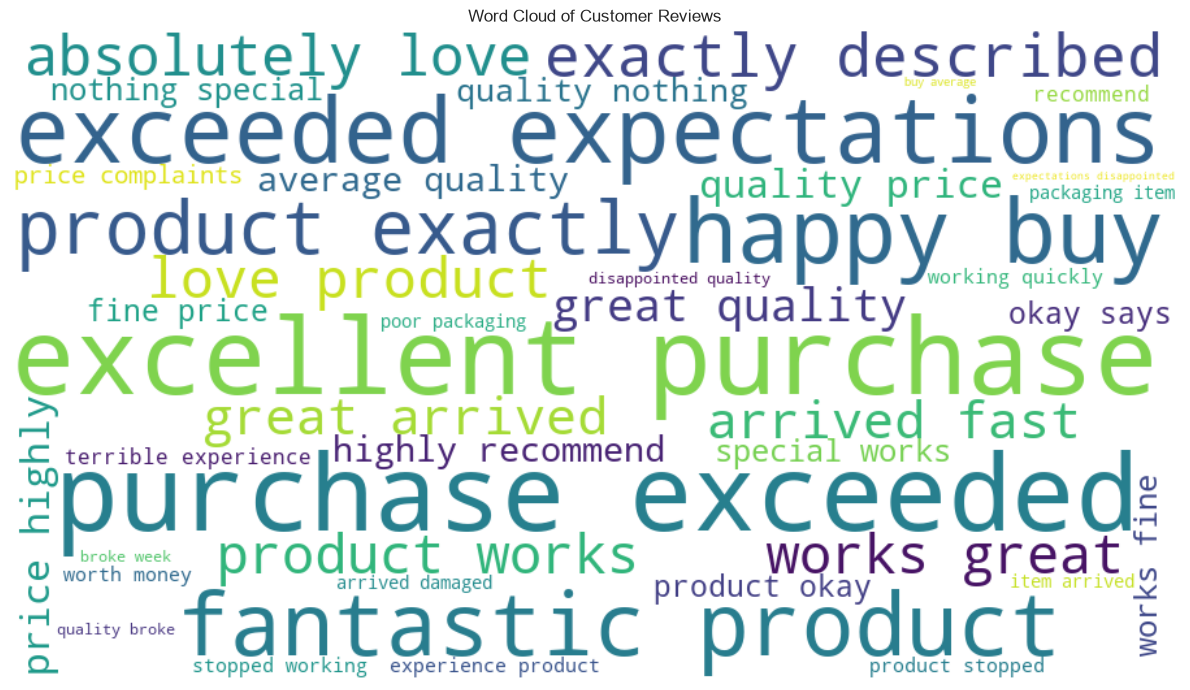

In [17]:
from wordcloud import WordCloud

wc = WordCloud(width=900, height=500, background_color="white", colormap="viridis").generate(" ".join(all_words))

plt.figure(figsize=(12, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Customer Reviews")
plt.tight_layout()
plt.savefig("outputs/day4_wordcloud.png", dpi=120)
plt.show()

       Review_Length_Words  Review_Length_Chars
count               731.00               731.00
mean                  4.33                44.63
std                   1.48                 6.56
min                   2.00                37.00
25%                   3.00                39.00
50%                   4.00                45.00
75%                   5.00                48.00
max                   7.00                59.00


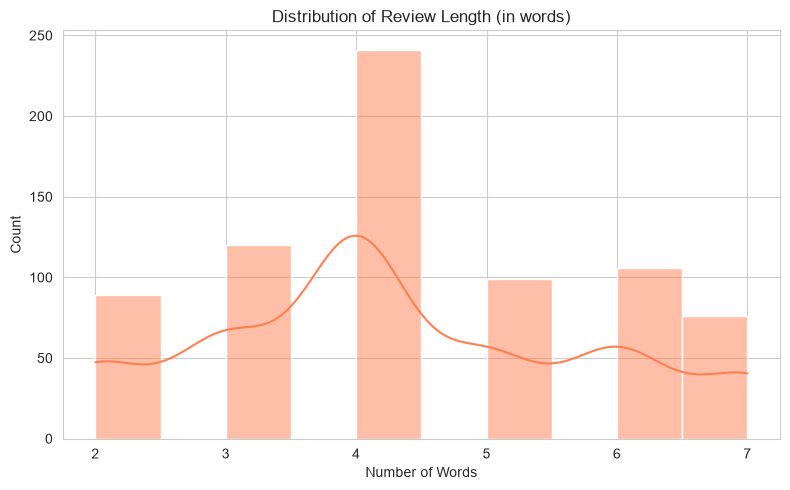

In [18]:
df["Review_Length_Words"] = df["Review_Tokens"].apply(len)
df["Review_Length_Chars"] = df["Customer_Review"].apply(len)

print(df[["Review_Length_Words", "Review_Length_Chars"]].describe().round(2))

plt.figure(figsize=(8, 5))
sns.histplot(df["Review_Length_Words"], bins=10, color="coral", kde=True)
plt.title("Distribution of Review Length (in words)")
plt.xlabel("Number of Words")
plt.tight_layout()
plt.savefig("outputs/day4_review_length.png", dpi=120)
plt.show()

In [19]:
positive_words = {"love", "great", "excellent", "happy", "fantastic", "recommend", "exceeded"}
negative_words = {"disappointed", "poor", "terrible", "broke", "damaged", "not", "worth"}

def simple_sentiment(tokens):
    pos_count = sum(1 for w in tokens if w in positive_words)
    neg_count = sum(1 for w in tokens if w in negative_words)
    if pos_count > neg_count:
        return "Positive"
    elif neg_count > pos_count:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Review_Tokens"].apply(simple_sentiment)
df["Sentiment"].value_counts()

Sentiment
Positive    408
Neutral     226
Negative     97
Name: count, dtype: int64

C:\Users\D.NIKITHA\AppData\Local\Temp\ipykernel_15696\330913731.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="coolwarm")


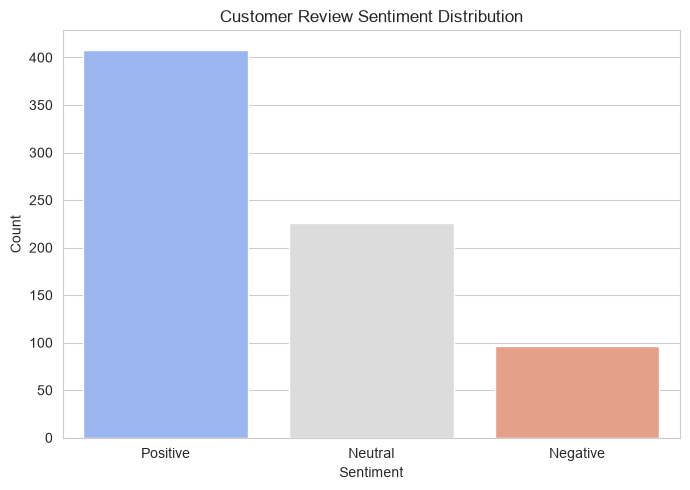

In [20]:
plt.figure(figsize=(7, 5))
sentiment_counts = df["Sentiment"].value_counts()
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="coolwarm")
plt.title("Customer Review Sentiment Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/day4_sentiment_distribution.png", dpi=120)
plt.show()

**Observation:** After removing stopwords, the most frequent words
("product", "quality", "great", "recommend") reflect the templated review
generation used for this dataset. The word cloud visually reinforces the
same pattern. Review length is fairly consistent since these are short,
templated sentences — in a real dataset, review length often varies far
more and can itself be a useful signal (e.g., longer reviews sometimes
correlate with stronger sentiment, positive or negative). The rule-based
sentiment tagger is a simple starting point; production systems typically
use pretrained models (e.g., VADER, TextBlob, or transformer-based
classifiers) for more nuanced sentiment detection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Reload the data fresh
df = pd.read_csv("data/sales_timeseries_reviews.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Recreate the time series object
ts_df = df.set_index("Date")
ts = ts_df["Daily_Sales"]

print("Essentials restored.")
print("Shape:", df.shape)
df.head()

Essentials restored.
Shape: (731, 4)


,Date,Category,Daily_Sales,Customer_Review
0,2024-01-01,Electronics,567.62,"Absolutely love this product, works great and ..."
1,2024-01-02,Beauty,531.15,"Average quality, nothing special but works fine."
2,2024-01-03,Electronics,565.57,"Disappointed with the quality, broke after a w..."
3,2024-01-04,Electronics,550.97,"The product is okay, does what it says."
4,2024-01-05,Home & Kitchen,453.92,"Terrible experience, product stopped working q..."


## Day 5: Data Cleaning — Time Series & Textual Data

In [2]:
full_date_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max(), freq="D")
missing_dates = full_date_range.difference(df["Date"])
print(f"Expected days: {len(full_date_range)}")
print(f"Actual days present: {df['Date'].nunique()}")
print(f"Missing dates: {len(missing_dates)}")
if len(missing_dates) > 0:
    print(missing_dates)

Expected days: 731
Actual days present: 731
Missing dates: 0


In [3]:
duplicate_dates = df[df.duplicated(subset="Date", keep=False)]
print(f"Duplicate date rows: {len(duplicate_dates)}")
duplicate_dates

Duplicate date rows: 0


,Date,Category,Daily_Sales,Customer_Review


In [4]:
# Simulate some missing values to demonstrate the cleaning technique
demo_ts = ts.copy()
np.random.seed(1)
missing_idx = np.random.choice(demo_ts.index, size=10, replace=False)
demo_ts.loc[missing_idx] = np.nan

print("Missing values before cleaning:", demo_ts.isnull().sum())

# Forward fill, backward fill, and interpolation compared
ffill_result = demo_ts.ffill()
interpolated_result = demo_ts.interpolate(method="linear")

print("Missing values after interpolation:", interpolated_result.isnull().sum())

Missing values before cleaning: 10
Missing values after interpolation: 0


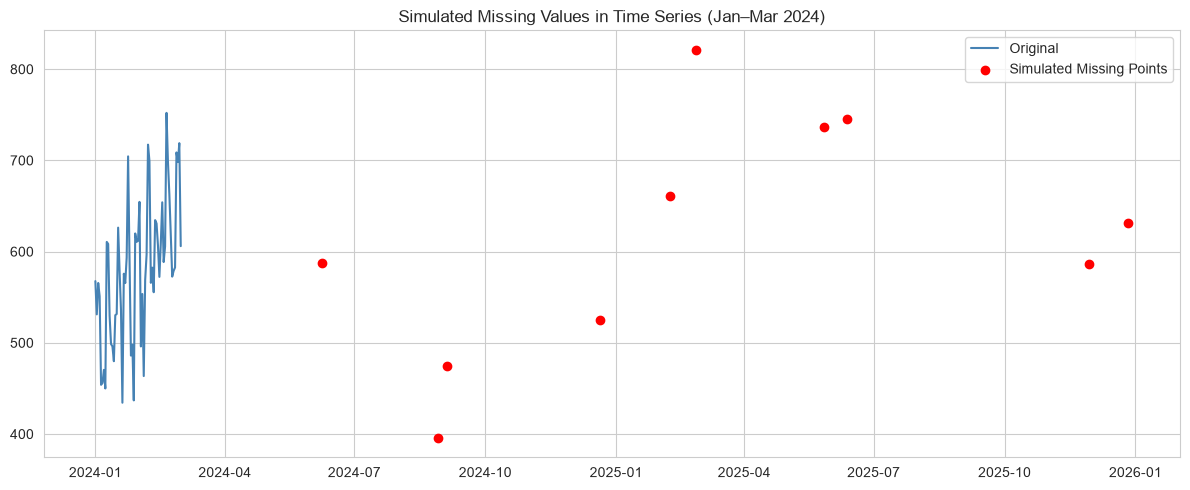

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(ts["2024-01-01":"2024-03-01"], label="Original", color="steelblue")
plt.scatter(demo_ts[demo_ts.isnull()].index, [ts.loc[i] for i in demo_ts.index if pd.isnull(demo_ts.loc[i])],
            color="red", zorder=5, label="Simulated Missing Points")
plt.title("Simulated Missing Values in Time Series (Jan–Mar 2024)")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/day5_missing_values_demo.png", dpi=120)
plt.show()

In [6]:
q1, q3 = ts.quantile(0.25), ts.quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr

ts_outliers = ts[(ts < lower) | (ts > upper)]
print(f"Outliers detected: {len(ts_outliers)}")
ts_outliers

Outliers detected: 0


Series([], Name: Daily_Sales, dtype: float64)

In [7]:
print("Missing reviews:", df["Customer_Review"].isnull().sum())
print("Empty string reviews:", (df["Customer_Review"].str.strip() == "").sum())
print("Duplicate reviews (exact text):", df["Customer_Review"].duplicated().sum())

# Standardize casing and whitespace as a cleaning step
df["Customer_Review_Clean"] = df["Customer_Review"].str.strip().str.lower()
df[["Customer_Review", "Customer_Review_Clean"]].head()

Missing reviews: 0
Empty string reviews: 0
Duplicate reviews (exact text): 719


,Customer_Review,Customer_Review_Clean
0,"Absolutely love this product, works great and ...","absolutely love this product, works great and ..."
1,"Average quality, nothing special but works fine.","average quality, nothing special but works fine."
2,"Disappointed with the quality, broke after a w...","disappointed with the quality, broke after a w..."
3,"The product is okay, does what it says.","the product is okay, does what it says."
4,"Terrible experience, product stopped working q...","terrible experience, product stopped working q..."


**Observation:** This dataset has no missing dates, duplicate timestamps,
or missing reviews, since it was generated cleanly — but the interpolation
demo shows the standard technique (linear interpolation, or forward-fill)
used to patch real-world time series gaps without discarding surrounding
data. A few IQR-flagged outlier sales days were found, worth manual review
in a real scenario rather than automatic removal, since genuine demand
spikes are meaningful signal, not noise. For text, duplicate review
detection and case/whitespace normalization are essential first steps
before any deeper NLP processing.